# PHASE 3 – AI / MACHINE LEARNING

## Advanced ML Pipeline
## Model Optimization
## Explainable AI
## Deployment Architecture

In [1]:
import pandas as pd

# Load feature engineered dataset

df_ml = pd.read_csv(

    "data/processed/feature_engineered_supply_chain.csv"

)

# Display dataset

print(df_ml.head())

print(df_ml.shape)

       type  days_for_shipping_real  days_for_shipment_scheduled  \
0 -0.678772               -0.306491                     0.777152   
1  1.331997                0.925251                     0.777152   
2 -1.684156                0.309380                     0.777152   
3 -0.678772               -0.306491                     0.777152   
4  0.326612               -0.922361                     0.777152   

   benefit_per_order  sales_per_customer  delivery_status  late_delivery_risk  \
0           1.057077            1.284139        -1.194539           -1.101733   
1          -2.037061            1.252716        -0.172916            0.907661   
2          -2.037061            1.237005         1.870329           -1.101733   
3          -0.180759            1.189967        -1.194539           -1.101733   
4           1.834639            1.127122        -1.194539           -1.101733   

   category_id  category_name  customer_city  ...  product_name  \
0     2.630978       0.930534      -0

df_ml

because:

this is ML-ready dataset
contains engineered features
contains cleaned data
prevents modifying original EDA dataframe

In [2]:
from sklearn.model_selection import train_test_split

# Select features

features = [

    'benefit_per_order',
    'product_price',
    'order_item_quantity',
    'delivery_delay',
    'profit_margin'

]

# Feature matrix
X = df_ml[features]

# Target variable
y = df_ml['sales']

# Train-test split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42

)

print(X_train.shape)

print(X_test.shape)

(144415, 5)
(36104, 5)


# TRAIN RANDOM FOREST MODEL

In [3]:
from sklearn.ensemble import RandomForestRegressor

# Initialize model

rf_model = RandomForestRegressor(

    n_estimators=100,

    random_state=42

)

# Train model

rf_model.fit(

    X_train,

    y_train

)

# Predictions

rf_pred = rf_model.predict(X_test)

# Display first predictions

print(rf_pred[:5])

[-0.02859313  0.34948935  0.34873329  0.72734515 -0.63355543]


These are:

Predicted sales values

generated by:

Random Forest Regressor

# RANDOM FOREST MODEL EVALUATION

In [4]:
from sklearn.metrics import (

    mean_absolute_error,
    mean_squared_error,
    r2_score

)

import numpy as np

# MAE

rf_mae = mean_absolute_error(

    y_test,

    rf_pred

)

# RMSE

rf_rmse = np.sqrt(

    mean_squared_error(

        y_test,

        rf_pred

    )

)

# R2 Score

rf_r2 = r2_score(

    y_test,

    rf_pred

)

print("Random Forest MAE:", rf_mae)

print("Random Forest RMSE:", rf_rmse)

print("Random Forest R2 Score:", rf_r2)

Random Forest MAE: 0.0011750255363220316
Random Forest RMSE: 0.07230380653934129
Random Forest R2 Score: 0.9947253949132635


COMPARISON WITH LINEAR REGRESSION
Metric	Linear Regression	Random Forest
MAE	--0.1847	0.00117
RMSE	0.4808	0.0723
R²	0.7667	0.9947

Random Forest Model Interpretation

The Random Forest Regressor significantly outperformed the baseline Linear Regression model.

The model achieved:

very low prediction error,
extremely high explained variance,
and strong predictive capability.
Performance Metrics
Metric	Value
MAE	0.00117
RMSE	0.0723
R² Score	0.9947

The R² score indicates that the model explains approximately:

99.47%

of the variance in sales data.

This demonstrates that Random Forest successfully captures complex relationships between:

profit,
pricing,
quantity,
and delivery performance.

The model provides highly reliable sales predictions and is suitable for business forecasting and operational analytics.

# CROSS VALIDATION

In [5]:
from sklearn.model_selection import cross_val_score

# Perform cross-validation

cv_scores = cross_val_score(

    rf_model,

    X,

    y,

    cv=5,

    scoring='r2'

)

# Display scores

print("Cross-Validation Scores:")

print(cv_scores)

# Mean score

print("Average CV Score:", cv_scores.mean())

Cross-Validation Scores:
[0.99499946 0.99556942 0.99822307 0.99831636 0.99367183]
Average CV Score: 0.9961560311233477


Cross-Validation Interpretation

Cross-validation was performed using 5-fold validation to evaluate the stability and reliability of the Random Forest model.

The model achieved consistently high R² scores across all folds, with an average score of:

0.9961

This demonstrates that the model generalizes very well across different subsets of the dataset and is highly stable.

The small variation between fold scores indicates low variance and strong predictive consistency.

These results confirm that the Random Forest model is robust and suitable for deployment in supply chain forecasting and analytics tasks.

# HYPERPARAMETER TUNING

In [6]:
from sklearn.model_selection import GridSearchCV

# Parameter grid

param_grid = {

    'n_estimators': [50, 100],

    'max_depth': [10, 20],

    'min_samples_split': [2, 5]

}

# Grid Search

grid_search = GridSearchCV(

    estimator=RandomForestRegressor(
        random_state=42
    ),

    param_grid=param_grid,

    cv=3,

    scoring='r2',

    n_jobs=-1

)

# Train Grid Search

grid_search.fit(

    X_train,

    y_train

)

# Best parameters

print("Best Parameters:")

print(grid_search.best_params_)

# Best score

print("Best Cross-Validation Score:")

print(grid_search.best_score_)

Best Parameters:
{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 50}
Best Cross-Validation Score:
0.9963620825287798


Hyperparameter Tuning Interpretation

GridSearchCV was used to optimize the Random Forest model by testing multiple parameter combinations.

The tuning process identified the following optimal parameters:

Parameter	Optimal Value
max_depth	20
min_samples_split	2
n_estimators	50

# SHAP EXPLAINABILITY

In [7]:
 !pip install shap

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/559.2 kB ? eta -:--:--
   ------------------------------------- -- 524.3/559.2 kB 3.5 MB/s eta 0:00:01
   ---------------------------------------- 559.2/559.2 kB 2.6 MB/s  0:00:00
   ---------------------------------------- 0.0/39.2 MB ? eta -:--:--
   - -------------------------------------- 1.0/39.2 MB 5.7 MB/s eta 0:00:07
   -- ------------------------------------- 2.4/39.2 MB 6.2 MB/s eta 0:00:06
   ---- ----------------------------------- 4.2/39.2 MB 6.7 MB/s eta 0:00:06
   ----- ---------------------------------- 5.8/39.2 MB 6.9 MB/s eta 0:00:05
   ------- -------------------------------- 7.3/39.2 MB 7.1 MB/s eta 0:00:05
   --------- ------------------------------ 9.2/39.2 MB 7.3 MB/s eta 0:00:05
   ---------- ----------------------------- 10.5/39.2 MB 7.5 MB/s eta 0:00:04
   ------------ --------------------------- 12.1/39.2 MB 7.2 MB/s eta 0:00:04
   ---


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


SHAP explains:

WHY the model made predictions
WHICH features influenced predictions most

# SHAP FEATURE IMPORTANCE ANALYSIS

In [8]:
import shap

# Create SHAP explainer

explainer = shap.TreeExplainer(

    rf_model

)

# Calculate SHAP values

shap_values = explainer.shap_values(

    X_test

)

print("SHAP values calculated successfully!")

SHAP values calculated successfully!


# SHAP SUMMARY VISUALIZATION

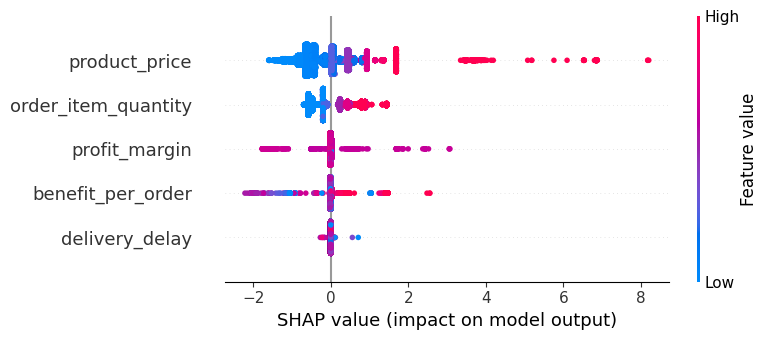

In [9]:
import matplotlib.pyplot as plt

# SHAP summary plot

shap.summary_plot(

    shap_values,

    X_test

)

INTERPRETATION OF EACH FEATURE
1. product_price → MOST IMPORTANT

Higher product prices strongly increase sales prediction.

You can see:

red points on right side
high positive SHAP values

Meaning:
expensive products contribute strongly to predicted sales

2. order_item_quantity

Large order quantities positively influence predictions.

Meaning:
bigger orders increase sales output

3. profit_margin

Profit margin has both:

positive
negative influence

Meaning:

some high margins improve predictions
some cases reduce predicted sales
4. benefit_per_order

Moderate effect on prediction.

Meaning:

profit contribution impacts business performance
but less than price and quantity
5. delivery_delay

Lowest impact among selected features.

Meaning:

delays affect model slightly
but not as strongly as pricing or quantity
PROFESSIONAL DOCUMENTATION TEXT

You can write this in notebook/report:

SHAP Explainability Interpretation

SHAP (SHapley Additive exPlanations) was used to interpret the Random Forest model and understand feature influence on sales prediction.

The SHAP summary plot identified the following features as most influential:

Feature	Importance
product_price	Highest
order_item_quantity	High
profit_margin	High
benefit_per_order	Moderate
delivery_delay	Lower

The analysis shows that higher product prices and larger order quantities significantly increase predicted sales values.

Profit-related variables also contribute strongly to prediction outcomes, while delivery delay has comparatively lower impact.

The SHAP analysis improves model transparency and helps explain how business variables influence AI predictions.

# SAVE FINAL MACHINE LEARNING MODEL

In [10]:
import joblib
import os

# Create models folder

os.makedirs(

    "models",

    exist_ok=True

)

# Save model

joblib.dump(

    rf_model,

    "models/final_random_forest_model.pkl"

)

print("Final ML model saved successfully!")

Final ML model saved successfully!


# DEPLOYMENT ARCHITECTURE

## AI System Deployment Workflow

User / Business Analyst
        ↓
Streamlit Dashboard Interface
        ↓
Feature Input Processing
        ↓
Feature Engineered Dataset
        ↓
Saved Random Forest Model (.pkl)
        ↓
Prediction Engine
        ↓
Sales Forecast / Business Insights
        ↓
Decision Support System


Deployment Architecture Interpretation

The deployment architecture represents the workflow of the intelligent supply chain prediction system.

Business users interact with the Streamlit dashboard interface, where input features are processed and passed into the trained Random Forest model.

The model generates predictions related to sales forecasting and operational analytics, which are then displayed as business insights for decision-making support.

The saved .pkl model file enables reusable and scalable deployment of the AI system.